## 0. Import and Definitions

In [46]:
import json
import os
import copy
from sklearn.metrics import roc_curve, auc

import scanpy as sc
import anndata as ad
from mudata import MuData

import numpy as np
import matplotlib.pyplot as plt

from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.analysis_utils import (
    Analyzer,
)
from src.analysis.logistic_regression import (
    train_classifier,
    generate_counterfactuals,
    init_classifier,
    evaluate_training_error,
)
from src.analysis.cluster_analysis import (
    plot_latent_means_umap,
)

from src.model.data_utils import (
    load_data,
    get_condition_shapes,
    get_condition_vocab,
    split_holdout_combinations,
    prepare_train_test_data,
    load_metacells,
    create_latent_adata,
)
from src.model.training import train_model
from src.model.build_model import get_model, remap_keys, init_config
from src.model.naming import resolve_checkpoint, holdout_suffix
from src.model.config import INNConfig
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_top_deg_violin,
    sample_from_means,
    plot_effect_size_comparison,
)
from src.analysis.pertubation_effects import (
    evaluate_de_effects,
)
from src.analysis.INN_OOD import (
    estimate_leftout_combo_mean,
    sample_leftout_combo_normal,
    sample_leftout_combo_shift,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
    observed_combos_from_adata,
)

import warnings
import socket
import torch

from sklearn.decomposition import PCA

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
adata = None
analyzer = None

## 1. Load Data

In [75]:
USE_METACELLS = True
DONOR = ["Donor1"]

# Which combos were held out of TRAINING. Point HOLDOUT_FILE at the same JSON the run
# used (train.py --holdout_file / train.sh HOLDOUT_FILE); ten combos give every OOD
# metric an error bar instead of one value on ~34 metacells. Set it to None to fall
# back to the single combo below, which is what older checkpoints were trained with.
HOLDOUT_FILE = "/home/jhoefer/sandbox/configs/holdout_combos.json"
HOLDOUT_COMBO = {"cytokine": "IL-2", "cell_type": "CD8 Memory"}  # used when HOLDOUT_FILE is None

if HOLDOUT_FILE is not None:
    with open(HOLDOUT_FILE) as handle:
        HOLDOUT_COMBOS = json.load(handle)
    # section 5 evaluates ONE combo at a time; take it from the set rather than
    # leaving the hardcoded value, so it is guaranteed to be one the model held out
    HOLDOUT_NAME, HOLDOUT_COMBO = next(iter(HOLDOUT_COMBOS.items()))
elif HOLDOUT_COMBO is not None:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {"combo_1": HOLDOUT_COMBO}, "combo_1"
else:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {}, None

# every combo in the set leaves training - holding out only the first would leave the
# other nine in the training data and then score them as though they were OOD
HOLDOUT_LIST = list(HOLDOUT_COMBOS.values())

# Factorized mixture prior: mu(cytokine, cell_type) = a_cell_type + b_cytokine, so the
# held-out combo's mean is composed from factors every other combo also trains, instead
# of being a free row that never receives a gradient and has to be guessed at eval time.
FACTORIZE_MEANS = True
# mu = a_ct + w_ct * b_cy instead of a + b (train.sh GAIN=1). Its own directory,
# because the gain scalar makes the checkpoint structurally different.
TREATMENT_GAIN = False

In [76]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [77]:
if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    # load_metacells skips load_data entirely (not just SEACells) once a cache for
    # this (dataset, top_genes, donors, group_keys) combination exists on disk.
    adata, labels_key, control_label = load_metacells(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        ["cell_type", "cytokine"],
        donors=DONOR,
        log_transform=True,
    )
    print(adata.X.shape)

mdata = MuData({"rna": adata})
dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

(12383, 1937)


## 2. Model

### 2.1 Setup

In [78]:
dataset_args["sigma_noise"] = 0.5
dataset_args["lam_MTC"] = 0.6
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 1024
prefix = ""
# part of the checkpoint name since train.py started recording them. This notebook's
# checkpoints predate the tokens, so resolve_checkpoint finds them by the legacy
# spelling; these values only matter once it is pointed at a newer run.
dataset_args["lr_means"] = 5e-4
dataset_args["latent_per_condition"] = 4
dataset_args["means_dim"] = None

In [79]:
conditions = [labels_key, "cell_type"]
condition_shapes = None
condition_type = None

# Fix the combo/condition vocabulary on the FULL adata, before any holdout filtering, so
# the held-out combo keeps a reserved slot in the one-hot encoding and in the
# mixture-prior means (see data_utils.get_condition_vocab). Every downstream consumer -
# the dataloaders, the model config, the Analyzer - has to be handed this same
# vocabulary, otherwise categories get re-inferred from whichever rows are present and
# every index past a missing combo silently points at the wrong row of `model.means`.
condition_categories, combo_categories = get_condition_vocab(adata, conditions)

if conditions is not None:
    condition_shapes = [len(condition_categories[c]) for c in conditions]
    condition_type = "mixture"
    trainable_means = True
    trainable_simga = True
print("Condition shapes:", condition_shapes)
print("Combo categories:", len(combo_categories))

# Hold the OOD combo out of TRAINING only - `adata` keeps every cell, so the evaluation
# below can still compare predictions against the real held-out ones.
if HOLDOUT_LIST:
    train_adata, holdout_adata = split_holdout_combinations(
        adata, HOLDOUT_LIST, group_keys=conditions
    )
    print(f"Held out {len(HOLDOUT_LIST)} combo(s); training on {train_adata.n_obs} of {adata.n_obs} cells.")
    print(f"Section 5 evaluates {HOLDOUT_NAME}: {HOLDOUT_COMBO}")
else:
    train_adata = adata

# Which combos actually have training rows - not the same as `combo_categories`, which is
# the full Cartesian product. Passed to the OOD helpers so untrained means rows cannot be
# averaged into a treatment shift.
observed_combos = observed_combos_from_adata(train_adata, conditions)

supervise_latent_meaning = "partition"
lam_supervise = 0.01


Condition shapes: [11, 18]
Combo categories: 198
Held out 10 combo(s); training on 11636 of 12383 cells.
Section 5 evaluates combo_1: {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}


In [80]:
test_size = 0.0

# train_adata (not adata): the held-out combo must not reach the training loader.
dataset, dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    train_adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
    test_size=test_size,
    combo_categories=combo_categories,
    condition_categories=condition_categories,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim


In [81]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes)
)
# knobs the filename is built from - train.py builds it from the same function, so a
# name typed here can no longer drift from the one written on disk.
name_knobs = dict(
    lam_MTC=lam_MTC,
    sigma_noise=sigma_noise,
    lr_means=dataset_args["lr_means"],
    latent_per_condition=dataset_args["latent_per_condition"],
    means_dim=dataset_args["means_dim"],
)

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

# the same components train.py appends, in the same order, from the same helper -
# a hardcoded string here is what made this notebook point at the non-factorized
# directory while its config asked for a factorized prior.
suffix = "_metacells" if USE_METACELLS else ""
suffix += holdout_suffix(holdout_file=HOLDOUT_FILE, combo=HOLDOUT_COMBO)
suffix += "_factorized" if FACTORIZE_MEANS else ""
suffix += "_gain" if TREATMENT_GAIN else ""
model_path += suffix
output_dir_path += suffix


plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

# None rather than raising: the cell below decides what to do about a missing
# checkpoint, and TRAIN_FROM_SCRATCH has to be set deliberately to accept one.
checkpoint_path = resolve_checkpoint(
    model_path, prefix=prefix, required=False, **name_knobs
)
print(f"Model path: {model_path}")
print(f"Checkpoint:  {checkpoint_path or 'NONE FOUND'}")

Model path: /g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized
Checkpoint:  /g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized/MTC_0.6_sigma_0.5_lrm_0.0005_lpc_4_model.pt


In [82]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}
val_metrics_loss = metrics_loss.copy()

In [83]:
model_config = INNConfig(
    N_dim=N_dim,
    N_blocks=8,
    condition_shapes=condition_shapes,
    pre_normalize=False,
    normalize=True,
    warmup_steps=2 * len(dataloader),
    condition_type=condition_type,
    trainable_means=trainable_means,
    n_clusters=len(combo_categories),
    lr_means=5e-3,
    supervise_latent_meaning=supervise_latent_meaning,
    lam_supervise=lam_supervise,
    trainable_sigma=trainable_simga,
    # vocabulary + holdout, so the config alone is enough to rebuild this model
    combo_categories=combo_categories,
    condition_categories=condition_categories,
    conditions=conditions,
    holdout_combos=HOLDOUT_LIST or None,
    # Factorized prior. `control_condition`/`control_label` pin the gauge so b_PBS = 0,
    # which makes a_cell_type the cell type's control mean and b_cytokine the treatment
    # effect. means_dim only needs room for sum(condition_shapes) mutually orthogonal
    # level vectors - it does not scale with the number of combos the way
    # latent_per_condition * n_clusters did.
    factorize_means=FACTORIZE_MEANS,
    control_condition=labels_key if FACTORIZE_MEANS else None,
    control_label=control_label if FACTORIZE_MEANS else None,
    means_dim=sum(condition_shapes) if FACTORIZE_MEANS else None,
    latent_per_condition=None if FACTORIZE_MEANS else 8,
    # ctrl_idx indexes a single condition's levels and is only read by the
    # "counterfactual"/"both" supervision modes; with combo labels it has no meaning.
    ctrl_idx=None,
)

flow, optimizer = get_model(model_config)


In [84]:
CONTINUE_TRAINING = False
# Guard for the branch below. Without it a missing checkpoint silently produced a
# randomly-initialised model and every plot in sections 3-5 was computed from it -
# a full set of plausible-looking figures with nothing marking them as meaningless.
TRAIN_FROM_SCRATCH = False
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

### 2.2 Train or Load 

In [85]:
print(checkpoint_path)

/g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized/MTC_0.6_sigma_0.5_lrm_0.0005_lpc_4_model.pt


In [86]:
if checkpoint_path is not None:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]

    if "val_metrics_loss" in checkpoint:
        val_metrics_loss = checkpoint["val_metrics_loss"]

    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]

    model_config = init_config(model_config)

    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    model, optimizer = get_model(model_config)

    model = model.to(device)
    saved_state = checkpoint["model_state_dict"]

    ## TODO: Remove fix
    # model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model = remap_keys(model, saved_state)

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])


elif TRAIN_FROM_SCRATCH:
    print("No checkpoint found; starting from a fresh model (TRAIN_FROM_SCRATCH).")
    model, optimizer = get_model(model_config)
    model = model.to(device)
else:
    raise FileNotFoundError(
        "No checkpoint found for these settings, so there is nothing to evaluate.\n"
        "Check prefix / lam_MTC / sigma_noise / lr_means / latent_per_condition "
        "against the files in:\n"
        f"  {model_path}\n"
        "or set TRAIN_FROM_SCRATCH = True to build an untrained model on purpose."
    )

if CONTINUE_TRAINING:
    # The loader above excludes HOLDOUT_COMBO; a checkpoint that was trained with a
    # different (or no) holdout would resume onto data it has already seen, quietly
    # turning the OOD evaluation into an in-distribution one.
    _ckpt_holdout = model_config.holdout_combos or None
    _nb_holdout = HOLDOUT_LIST or None
    assert _ckpt_holdout == _nb_holdout, (
        f"Checkpoint holdout {_ckpt_holdout} != notebook HOLDOUT_COMBO {_nb_holdout}. "
        "Resuming would train on the combo you intend to evaluate OOD."
    )

    print(f"Starting training from epoch {start_epoch}...")

    model, optimizer, metrics_loss, val_metrics_loss, log_path = train_model(
        model,
        optimizer,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        save_model_path=checkpoint_path,
        model_config=model_config,
        val_metrics_loss=val_metrics_loss,
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
    )

Checkpoint found at epoch 1230.
Loaded successfully. Missing/fresh keys: []


### 2.3 OOD probe history

What the OOD metrics were doing *during* training, for the held-out combos. The
training NLL keeps improving for hours; this shows whether OOD prediction improved
with it or peaked early and drifted, which is what decides whether the last
checkpoint is the one worth evaluating.

Empty unless the run recorded a probe - `PROBE_MODE=holdout sbatch train.sh`, or
`--probe_holdout` / `--probe_combo` on train.py. Read `peak_frac`: 1.0 means the
metric was still improving at the end, a small value means it peaked that early in
the run and everything after was drift.

25 probes over epochs 0-1200 on 10 holdout combos
              best  peak_epoch  peak_frac   final  decay_from_peak  NLL_at_peak  NLL_final
metric                                                                                    
mmd         0.0224         550     0.4583  0.0225          -0.0001    -671.2622  -775.1143
r2_top50    0.7259        1200     1.0000  0.7259           0.0000    -734.0588  -775.1143
cos2_top50  0.7413        1200     1.0000  0.7413           0.0000    -734.0588  -775.1143
accuracy    0.8102         700     0.5833  0.7585           0.0517    -687.1445  -775.1143
var_ratio   1.0024         800     0.6667  0.9721           0.0303    -689.4935  -775.1143

per-combo peak epochs:
          mmd_peak  r2_top50_peak  cos2_top50_peak  accuracy_peak  var_ratio_peak
combo                                                                            
combo_1        600           1200              700            150             400
combo_10       200           1200          

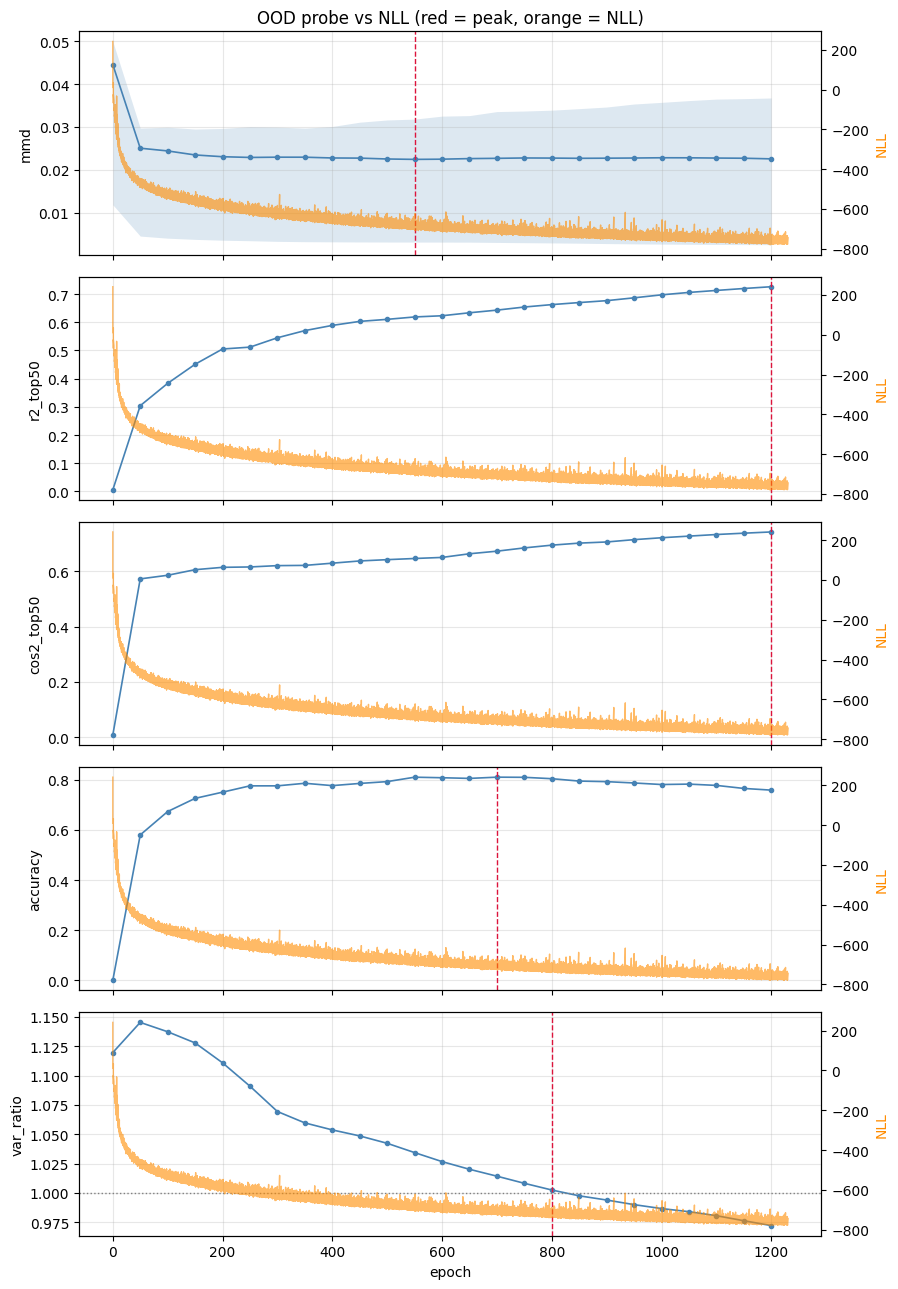

In [87]:
from src.analysis.ood_history import analyze, nll_frame

# `checkpoint` and `metrics_loss` are already in memory from 2.2, so the history is
# read straight out of them - `analyze(checkpoint_path)` would work too, but pays a
# second ~7.6 GB torch.load for data this notebook already holds.
ood = analyze(
    checkpoint.get("ood_history") if checkpoint_path is not None else [],
    nll=nll_frame(metrics_loss),
    plot_path=os.path.join(plot_dir, "ood_probe_history.png"),
)

### 2.4 Treatment gain weights

Only for a `--treatment_gain` model (`TREATMENT_GAIN = True` above). The gain
relaxes the prior to `mu = a_ct + w_ct * (b_cy - b_ctrl)`, so `w` is one scalar per
cell type saying how strongly it responds to the single shared treatment direction.
It rescales the shift; it cannot rotate it.

**Only ratios of `w` are meaningful** - `w * b` has a global scale redundancy, so the
column to read is `w_rel` (gain / median gain). Weights start at 1.0, so an all-1.0
column means the parameter never moved and the run is effectively additive.
`real_amplitude` is the empirical counterpart: how far each cell type actually moves
from control in the data, averaged over cytokines.

In [88]:
from src.analysis.gain_weights import analyze_gain

# returns None (and says so) for an additive model, so the cell is safe to run
# whatever checkpoint is loaded - `model_config` comes from the checkpoint itself,
# so it reflects what was trained rather than the TREATMENT_GAIN flag above.
gain = analyze_gain(
    model,
    model_config,
    adata=adata,
    control_label=control_label,
    plot_path=os.path.join(plot_dir, "treatment_gain_weights.png"),
)

This model has no treatment_gain parameter (train with --treatment_gain / GAIN=1 to get one).


In [89]:
analyzer = Analyzer(
    adata,
    model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path,
    metrics_loss,
    conditions=conditions,
    condition_type=model_config.condition_type,
    val_metrics_loss=val_metrics_loss,
    combo_categories=combo_categories,
    condition_categories=condition_categories,
)

## 3. Evaluation

### 3.1 Clusters

In [ ]:
plot_latent_means_umap(analyzer)

#### 3.1.1 Latent Dimension Split UMAP

In [ ]:
def plot_latent_dims_split_umap(analyzer, M, color=None, random_state=42):
    latent_adata = create_latent_adata(
        analyzer.adata,
        analyzer.model,
        analyzer.device,
        analyzer.conditions,
        analyzer.condition_type,
    )
    Z = latent_adata.X
    total_dims = Z.shape[1]

    if color is None:
        color = [analyzer.labels_key]

    splits = {
        f"dims_0-{M}": Z[:, :M],
        f"dims_{M}-{total_dims}": Z[:, M:],
    }

    for name, Z_split in splits.items():
        split_adata = ad.AnnData(X=Z_split.astype("float32"), obs=latent_adata.obs.copy())
        sc.pp.neighbors(split_adata)
        sc.tl.umap(split_adata, random_state=random_state)
        sc.pl.umap(split_adata, color=color, title=f"Latent UMAP — {name}")
        plt.savefig(
            os.path.join(analyzer.plot_dir, f"latent_umap_{name}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [ ]:
if analyzer.condition_type == "conditional":
    M = analyzer.model.means_dim
else:
    M = 500
plot_latent_dims_split_umap(analyzer, M)

In [ ]:
def comapare_learned_vs_empirical_means(analyzer):
    latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)

    empirical_means = []

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    for key in perturbations:
        mask = analyzer.adata.obs[f"{analyzer.labels_key}"] == key
        empirical_means.append(latent_adata[mask].X.mean(axis=0))

    empirical_means = np.array(empirical_means)

    with torch.no_grad():
        learned_means = analyzer.model.means.cpu().numpy()

    return empirical_means, learned_means


def plot_learned_vs_empirical_means(empirical_means, learned_means, analyzer):

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    n = len(perturbations)
    combined = np.concatenate([empirical_means, learned_means], axis=0)

    pca = PCA(n_components=2)
    combined_2d = pca.fit_transform(combined)
    empirical_2d = combined_2d[:n]
    learned_2d = combined_2d[n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap("tab10" if n <= 10 else "tab20")

    for i, label in enumerate(perturbations):
        color = cmap(i % cmap.N)
        ax.scatter(*empirical_2d[i], color=color, marker="o", s=80)
        ax.scatter(*learned_2d[i], color=color, marker="x", s=100)
        ax.annotate(label, empirical_2d[i], fontsize=8, alpha=0.8)

    # Legend explaining marker shapes (not per-perturbation, just style)
    ax.scatter([], [], color="black", marker="o", label="Empirical mean")
    ax.scatter([], [], color="black", marker="x", label="Learned mean")
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("Empirical vs. learned perturbation means (PCA)")
    fig.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, "empirical_vs_learned_means.png"), dpi=300
    )
    plt.show()

In [ ]:
emp_means, learned_means = comapare_learned_vs_empirical_means(analyzer)
plot_learned_vs_empirical_means(emp_means, learned_means, analyzer)

### 3.2 Counterfactuals

In [ ]:
key = "IL-2"

In [ ]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [ ]:
(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    cfs_train_dataset,
    cfs_adata_train,
    cfs_num_classes,
) = init_classifier(
    analyzer_cfs, key, latent=False, hidden_dim=None, labels_key="origin"
)

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    weights,
    analyzer_cfs.device,
    num_epochs=10,
)

In [ ]:
evaluate_training_error(
    analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies
)

In [ ]:
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.3 MMD

In [ ]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.4 Mean Expressions

In [ ]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="EOFlow")

In [ ]:
plot_effect_size_comparison(analyzer, key=key, top_n=10, method="Means", cfs_fn=generate_counterfactuals)

### 3.5 Violin Plots

In [ ]:
key = "IL-2"

In [ ]:
from src.analysis.logistic_regression import generate_counterfactuals
from src.utils.utils import extract_top_genes, normalize_log1p
import scanpy as sc
import pandas as pd


def plot_top_deg_violin(
    analyzer, key, cfs_fn=generate_counterfactuals, log1p_transform=False, gene_idx=0
):
    top_gene_names, gene_indices = extract_top_genes(
        analyzer, key, top_n=20, log1p_transform=log1p_transform
    )
    gene_name = top_gene_names[gene_idx]
    gene_idx = gene_indices[gene_idx]

    def gene_values(adata_subset):
        x = (
            adata_subset.X.toarray()
            if hasattr(adata_subset.X, "toarray")
            else adata_subset.X
        )
        if log1p_transform:
            x = normalize_log1p(x)
        return x[:, gene_idx]

    control_values = gene_values(
        analyzer.adata[
            analyzer.adata.obs[analyzer.labels_key] == analyzer.control_label
        ]
    )
    key_values = gene_values(
        analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key]
    )

    x_cfs, z_cfs, all_source_labels, _ = cfs_fn(analyzer, key=key)
    # counterfactual = control cells predicted forward to `key`, matching the classic
    # ctrl -> stim comparison (rather than pooling counterfactuals from every source)
    cf_mask = np.asarray(all_source_labels) == analyzer.control_label
    cf_values = (
        x_cfs[cf_mask, gene_idx]
        .clip(
            min=0, max=1.1 * np.quantile(x_cfs[cf_mask, gene_idx].cpu().numpy(), 0.999)
        )
        .cpu()
        .numpy()
    )

    cf_label = f"{key} (counterfactual)"
    order = [analyzer.control_label, cf_label, key]
    values = np.concatenate([control_values, cf_values, key_values]).astype(np.float32)
    groups = (
        [analyzer.control_label] * len(control_values)
        + [cf_label] * len(cf_values)
        + [key] * len(key_values)
    )

    violin_adata = ad.AnnData(
        X=values.reshape(-1, 1),
        var=pd.DataFrame(index=[str(gene_name)]),
        obs=pd.DataFrame({"group": pd.Categorical(groups, categories=order)}),
    )

    ax = sc.pl.violin(
        violin_adata,
        keys=str(gene_name),
        groupby="group",
        order=order,
        use_raw=False,
        xlabel="",
        ylabel="expression",
        show=False,
    )
    ax.set_title(f"Top DEG for {key}: {gene_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(analyzer.plot_dir, f"top_deg_violin_{key}.png"), dpi=300)
    plt.show()

In [ ]:
plot_top_deg_violin(analyzer, key=key, gene_idx=0)

In [ ]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby=analyzer.labels_key,
    groups=[key],
    reference=analyzer.control_label,
    method="wilcoxon",
)
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby=f"{analyzer.labels_key}", standard_scale="var", n_genes=20
)

### 3.6 CF UMAP

In [ ]:
adata_sampled = sample_from_means(analyzer, sigma=1.0)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_original.png"), dpi=300)

sc.pp.neighbors(adata_sampled)
sc.tl.umap(adata_sampled)
sc.pl.umap(adata_sampled, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_sampled.png"), dpi=300)

## 4. Cytokine Effects

### 4.1 Bottlenecks

In [ ]:
def get_perturbation_dim_importance(analyzer, perturbation, control_label=None, trick=False):
    """
    Rank latent dimensions by their importance for a specific perturbation,
    based on the displacement of the perturbation mean from the control mean.
    """
    if control_label is None:
        control_label = analyzer.control_label

    dataset = analyzer.kwargs_data["dataset"]
    categories = dataset.cats[0].categories.tolist()
    means = analyzer.model.means.detach().cpu()  # (K, N_dim)

    pert_idx = categories.index(perturbation)
    ctrl_idx = categories.index(control_label)
    if trick:
        pert_idx += 1

    pert_mean = means[pert_idx]  # (N_dim,)
    ctrl_mean = means[ctrl_idx]  # (N_dim,)

    # displacement vector: how much does this perturbation shift each dim
    delta = pert_mean - ctrl_mean  # (N_dim,)

    # rank by absolute displacement
    importance = torch.abs(delta)
    dim_order = torch.argsort(importance, descending=True)

    return dim_order.numpy(), delta.numpy()

In [ ]:
if analyzer.jac_dec is None:
    analyzer.compute_jacobian()

In [ ]:
RANDOM = True
MEANS = False
pert = "IL-4"
trick = True

In [ ]:
perturbations = adata.obs[labels_key].unique()
perturbations = [c for c in perturbations if c != control_label]

FULL_DE = False

keep_dims = [N_dim, 1700, 1500, 1000, 750, 500, 250, 100, 75, 50, 25, 10, 5, 3, 0]
vae_bottlenecks = []

if RANDOM:
    analyzer.latent_sort = torch.randperm(N_dim)
    analyzer.latent_sort = torch.arange(N_dim)  
elif MEANS:
    if pert is None:
        raise ValueError("Please specify a perturbation for MEANS sorting.")
    else:
        perturbations = [pert]
        analyzer.latent_sort, _ = get_perturbation_dim_importance(
            analyzer, perturbation=pert, control_label=control_label, trick=trick
        )

In [ ]:
(
    rhos,
    direction_agreements,
    top_overlaps,
    lfc_shifts,
    rhos_pca,
    direction_agreements_pca,
    top_overlaps_pca,
    lfc_shifts_pca,
    rhos_vae,
    direction_agreements_vae,
    top_overlaps_vae,
    lfc_shifts_vae,
) = evaluate_de_effects(
    analyzer,
    perturbations,
    keep_dims,
    vae_bottlenecks,
    batch_size=1024,
    use_noise=False,
    FULL_DE=FULL_DE,
)

In [ ]:
metrics = [
    ("Spearman Rho", rhos, rhos_pca),
    ("Direction Agreement", direction_agreements, direction_agreements_pca),
    ("Top 100 Overlap", top_overlaps, top_overlaps_pca),
    ("LFC Shift", lfc_shifts, lfc_shifts_pca),
]

colors = [
    f"tab:{c}"
    for c in ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray"]
]

fig, axes = plt.subplots(len(metrics), 2, figsize=(10, 5 * len(metrics)), sharey="row")

for row, (label, flow_vals, pca_vals) in enumerate(metrics):
    for col, (vals, linestyle, tag) in enumerate(
        [
            (flow_vals, "solid", "Flow"),
            (pca_vals, "dashed", "PCA"),
        ]
    ):
        a = axes[row, col]
        for i, pert in enumerate(perturbations):
            a.plot(
                keep_dims,
                vals.T[i],
                marker="o",
                color=colors[i % len(colors)],
                linestyle=linestyle,
                label=pert,
            )
        a.set_title(f"{label} — {tag}")
        a.set_xlabel("First n nonzero Latent Dims")
        a.set_ylabel(label)
        a.legend()
        a.grid()

plt.suptitle("DE Result Stability vs. Number of Latent Dims", fontsize=14)
plt.tight_layout()

de = "full" if FULL_DE else "lfc"
postfix = "_means" if MEANS else ""
postfix += "_random" if RANDOM else ""
postfix += "_trick" if trick else ""
name = f"DE_stability_vs_latent_dims_{de}_{postfix}"
plt.savefig(os.path.join(analyzer.plot_dir, f"{name}.png"))
plt.show()

## 5. OOD

In [ ]:
# the checkpoint's own set, not the notebook's: it is what this model actually held
# out, and with a ten-combo file the two can disagree if HOLDOUT_FILE was edited.
holdout_combo = list(model_config.holdout_combos or [])

# 5.x evaluates one combo. Prefer the notebook's, so the section title and the
# figures agree; fall back to the checkpoint's first with a warning rather than
# silently scoring a combo the model was trained on.
ood_combo = HOLDOUT_COMBO if HOLDOUT_COMBO in holdout_combo else holdout_combo[0]
if ood_combo != HOLDOUT_COMBO:
    print(f"WARNING: {HOLDOUT_COMBO} is not in the checkpoint's holdout set; "
          f"section 5 falls back to {ood_combo}.")

print(f"Checkpoint held out {len(holdout_combo)} combo(s); evaluating {ood_combo}")

estimate_leftout_combo_mean(
    model=analyzer.model,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
)

### 5.1 Sampling strategy 1: Normal around the estimated mean

Draw fresh latent points from an isotropic Normal centered on the mean estimated above, then decode.

In [ ]:
adata_ood_normal = sample_leftout_combo_normal(
    model=analyzer.model,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
    n_samples=500,
    sigma=1.0,
    var=analyzer.adata.var,
)
adata_ood_normal

### 5.2 Sampling strategy 2: encode control cells, shift, decode

Take real `PBS`-treated cells of the held-out cell type, encode them, shift by the same average treatment-control latent shift used above, then decode - this carries over each real cell's own latent structure instead of drawing fresh isotropic noise.

In [ ]:
adata_ood_shift = sample_leftout_combo_shift(
    model=analyzer.model,
    adata=analyzer.adata,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
)
adata_ood_shift

### 5.3 Evaluation: MMD and mean expressions

Compares both OOD sampling strategies against the real held-out-combo cells - present in
`analyzer.adata` even though the model never trained on them, since only the training
script's `split_holdout_combinations` call excluded them, not `load_data`.

`scoped_analyzer_for_combo` restricts `.adata` to just the held-out cell type so
`analyzer.labels_key` ("cytokine") alone resolves to this combo, letting the same MMD and
mean-expression helpers used for the regular counterfactual evaluation (sections 3.3/3.4)
be reused unchanged via `cfs_fn_from_adata`.

In [ ]:
ood_key = ood_combo["cytokine"]

scoped_analyzer = scoped_analyzer_for_combo(
    analyzer,
    ood_combo,
    conditions=["cytokine", "cell_type"],
    condition_key="cytokine",
    cell_type_key="cell_type",
)

ood_predictions = {
    "Normal": adata_ood_normal,
    "Shift": adata_ood_shift,
}

print(f"Real held-out cells found: {scoped_analyzer.adata.obs['cytokine'].value_counts()[ood_key]}")

In [ ]:
mmd_results, ood_ctrl_mmd = evaluate_leftout_combo_mmd(
    scoped_analyzer, ood_predictions, key=ood_key, plot_dir=analyzer.plot_dir
)
print(f"Control MMD (random split of real): {ood_ctrl_mmd:.4f}")
print(mmd_results)

In [ ]:
fig, axes = plt.subplots(2, len(ood_predictions), figsize=(6 * len(ood_predictions), 10))

for col, (name, adata_pred) in enumerate(ood_predictions.items()):
    cfs_fn = cfs_fn_from_adata(adata_pred, source_label=name)

    plot_mean_expression_comparison(
        scoped_analyzer, key=ood_key, top_n=10, cfs_fn=cfs_fn, method=f"OOD {name}", ax=axes[0, col]
    )
    plot_effect_size_comparison(
        scoped_analyzer, key=ood_key, top_n=10, cfs_fn=cfs_fn, method=f"OOD {name}", ax=axes[1, col]
    )

plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"leftout_combo_mean_expression_{ood_key}.png"), dpi=300)
plt.show()